# Unit 7: 实战项目 —— 完整 BCI 流水线

## 项目概述

将前 6 个 Unit 所学的全部知识整合为一个完整的脑机接口应用：

```text
┌──────────────────────────────────────────────────────────┐
│                    实时 BCI 系统                          │
│                                                          │
│  [Synthetic Board] ──→ [信号预处理] ──→ [特征提取]       │
│         │                    │               │           │
│    BoardShim API      DataFilter API    DataFilter API   │
│                              │               │           │
│                              └───→ [ML推理] ←──┘          │
│                                      │                   │
│                                 MLModel API              │
│                                      │                   │
│                              [实时可视化界面]             │
│                          pyqtgraph / matplotlib          │
└──────────────────────────────────────────────────────────┘
```

## 学习目标
- 实现从数据采集到 ML 推理的完整闭循环
- 使用滑动窗口实时计算频带功率
- 集成 BrainFlow ML 模型持续评估心理状态
- 构建交互式可视化界面
- 掌握实时系统的设计模式

In [16]:
import os
import time
import threading
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

from brainflow.board_shim import (
    BoardShim, 
    BrainFlowInputParams, 
    BoardIds,
    BrainFlowPresets
)
from brainflow.data_filter import (
    DataFilter, 
    FilterTypes, 
    WaveletTypes, 
    NoiseTypes, 
    AggOperations,
    DetrendOperations, 
    WindowOperations,
    
)
from brainflow.ml_model import (
    MLModel, 
    BrainFlowMetrics, 
    BrainFlowClassifiers, 
    BrainFlowModelParams
)

print("模块导入完成")

# 关闭日志记录
BoardShim.disable_board_logger()
print("日志记录已关闭")

模块导入完成
日志记录已关闭


## Part A: 基于 matplotlib 的轻量级实时系统

首先使用 matplotlib 动画实现一个轻量版本，不依赖 pyqtgraph。

In [3]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import display, clear_output

# 设置中文字体
if os.name == 'nt':
    plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False
elif os.name == 'posix': # macos 或 linux
    plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Arial Unicode MS', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False
print("中文字体设置完成")

%matplotlib inline

中文字体设置完成


prepare() 的功能是：

* 加载模型文件到内存
* 初始化内部权重
* 准备预测调用


BrainFlow 的 ML 模型 底层是单例管理的（C++ DLL 层面）。

* 在同一个进程里，同时只能有 一个 ML 模型处于“已 prepare”状态。
* 当你调用 self.restfulness_model.prepare() 后，再调用另一个模型的 prepare() 时，就会报这个错。

换句话说：

* MLModel.prepare() 并不是完全独立的，每个实例的 prepare 不能同时存在。
* 底层 DLL 会认为：“已经有一个模型被 prepare 了，不能再 prepare 另一个。”

In [11]:
class BCIRealTimeSystem:
    """
    实时 BCI 系统：数据采集 → 信号处理 → 特征提取 → ML推理 → 可视化
    """
    
    def __init__(self, board_id=BoardIds.SYNTHETIC_BOARD, 
                 window_sec=4, update_interval=0.5):
        """
        Args:
            board_id: BrainFlow 板卡 ID
            window_sec: 分析窗口大小（秒）
            update_interval: 更新间隔（秒）
        """
        self.board_id = board_id
        self.window_sec = window_sec
        self.update_interval = update_interval
        
        # 板卡信息
        self.descr = BoardShim.get_board_descr(board_id)
        self.sampling_rate = self.descr['sampling_rate']
        self.eeg_channels = self.descr['eeg_channels']
        self.eeg_names = BoardShim.get_eeg_names(board_id)
        self.ts_channel = self.descr['timestamp_channel']
        
        # 窗口参数
        self.window_samples = int(window_sec * self.sampling_rate)
        
        # 数据缓冲区（用于实时可视化）
        self.data_history = deque(maxlen=500)
        self.metric_history = {
            'restfulness': deque(maxlen=200),
            'mindfulness': deque(maxlen=200),
        }
        
        # 状态
        self.board = None
        self.running = False
        
        # ML 模型初始化
        self._init_models()
        
        print(f"系统就绪 | 板卡: {self.descr['name']} | "
              f"采样率: {self.sampling_rate} Hz | "
              f"窗口: {window_sec}秒 ({self.window_samples}样本)")
    
    def _init_models(self):
        """初始化 ML 模型"""
        self.restfulness_model = MLModel(BrainFlowModelParams(
            BrainFlowMetrics.RESTFULNESS.value,
            BrainFlowClassifiers.DEFAULT_CLASSIFIER.value
        ))
        
        self.mindfulness_model = MLModel(BrainFlowModelParams(
            BrainFlowMetrics.MINDFULNESS.value,
            BrainFlowClassifiers.DEFAULT_CLASSIFIER.value
        ))
        print("ML 模型初始化就绪")
    
    def start(self):
        """启动数据采集"""
        params = BrainFlowInputParams()
        self.board = BoardShim(self.board_id, params)
        self.board.prepare_session()
        self.board.start_stream(450000) # 450000 是 1800 秒的采样时间
        self.running = True
        print("数据流已启动")
    
    def stop(self):
        """停止数据采集并释放资源"""
        self.running = False
        if self.board is not None:
            try:
                self.board.stop_stream()
                self.board.release_session()
            except Exception:
                pass
            self.board = None
        
        # self.restfulness_model.release()
        # self.mindfulness_model.release()
        print("资源已释放")
    
    def _preprocess_eeg(self, eeg_data_2d):
        """对提取的 EEG 数据执行标准预处理"""
        n_channels = eeg_data_2d.shape[0]
        processed = np.zeros_like(eeg_data_2d, dtype=np.float64)
        
        for i in range(n_channels):
            ch_data = eeg_data_2d[i, :].copy().astype(np.float64)
            DataFilter.detrend(ch_data, DetrendOperations.LINEAR.value)
            DataFilter.perform_bandpass(ch_data, self.sampling_rate,
                                         0.5, 50.0, 4,  # 0.5-50 Hz
                                         FilterTypes.BUTTERWORTH.value, 0)
            DataFilter.remove_environmental_noise(ch_data, self.sampling_rate, NoiseTypes.FIFTY.value)
            processed[i, :] = ch_data
        
        return processed
    
    def analyze(self):
        """
        执行一轮分析：获取数据 → 预处理 → 特征提取 → ML推理
        
        Returns:
            dict 包含分析结果
        """
        if self.board is None:
            return None
        
        # 获取当前缓冲区的数据
        current_data = self.board.get_current_board_data(self.window_samples)
        
        if current_data.shape[1] < self.window_samples // 2:
            return None  # 数据不足
        
        # 提取 EEG 通道
        eeg_2d = current_data[self.eeg_channels, :].astype(np.float64)
        
        # 预处理
        processed_eeg = self._preprocess_eeg(eeg_2d)
        
        # 频带功率特征
        band_result = DataFilter.get_avg_band_powers(
            processed_eeg,
            list(range(len(self.eeg_channels))),
            self.sampling_rate,
            False  # 已手动预处理，不再应用内部滤波器
        )
        band_powers = band_result[0]
        
        # ML 推理
        self.restfulness_model.prepare()
        r = self.restfulness_model.predict(band_powers)
        restfulness = float(r[0]) if isinstance(r, (list, np.ndarray)) else float(r)
        self.restfulness_model.release()
        
        self.mindfulness_model.prepare()
        m = self.mindfulness_model.predict(band_powers)
        mindfulness = float(m[0]) if isinstance(m, (list, np.ndarray)) else float(m)
        self.mindfulness_model.release()    
        
        # 记录历史
        # 把预处理后的第 1 个 EEG 通道的一小段数据保存到历史记录里，通常用于后续绘图、展示或调试
        self.data_history.append(processed_eeg[0, :self.window_samples // 4].tolist())
        self.metric_history['restfulness'].append(restfulness)
        self.metric_history['mindfulness'].append(mindfulness)
        
        return {
            'band_powers': band_powers,
            'restfulness': restfulness,
            'mindfulness': mindfulness,
        }


## 运行实时系统

启动系统并观察实时分析结果。**注意：这是演示模式，Synthetic Board 生成的是模拟信号。**

In [12]:
# 初始化并启动系统
bci = BCIRealTimeSystem(
    board_id=BoardIds.SYNTHETIC_BOARD,
    window_sec=4,
    update_interval=0.5
)
bci.start()

# 等待数据积累
print("等待数据积累...")
time.sleep(5)

# 执行几轮分析
print("\n=== 实时分析结果 ===\n")
for i in range(5):
    result = bci.analyze()
    if result:
        print(f"[第{i+1}轮] "
              f"放松度={result['restfulness']:.3f} | "
              f"正念度={result['mindfulness']:.3f}")
    time.sleep(1)

print(f"\n历史记录: {len(bci.metric_history['restfulness'])} 轮")

ML 模型初始化就绪
系统就绪 | 板卡: Synthetic | 采样率: 250 Hz | 窗口: 4秒 (1000样本)
数据流已启动
等待数据积累...

=== 实时分析结果 ===

[第1轮] 放松度=0.000 | 正念度=1.000
[第2轮] 放松度=0.000 | 正念度=1.000
[第3轮] 放松度=0.000 | 正念度=1.000
[第4轮] 放松度=0.000 | 正念度=1.000
[第5轮] 放松度=0.000 | 正念度=1.000

历史记录: 5 轮


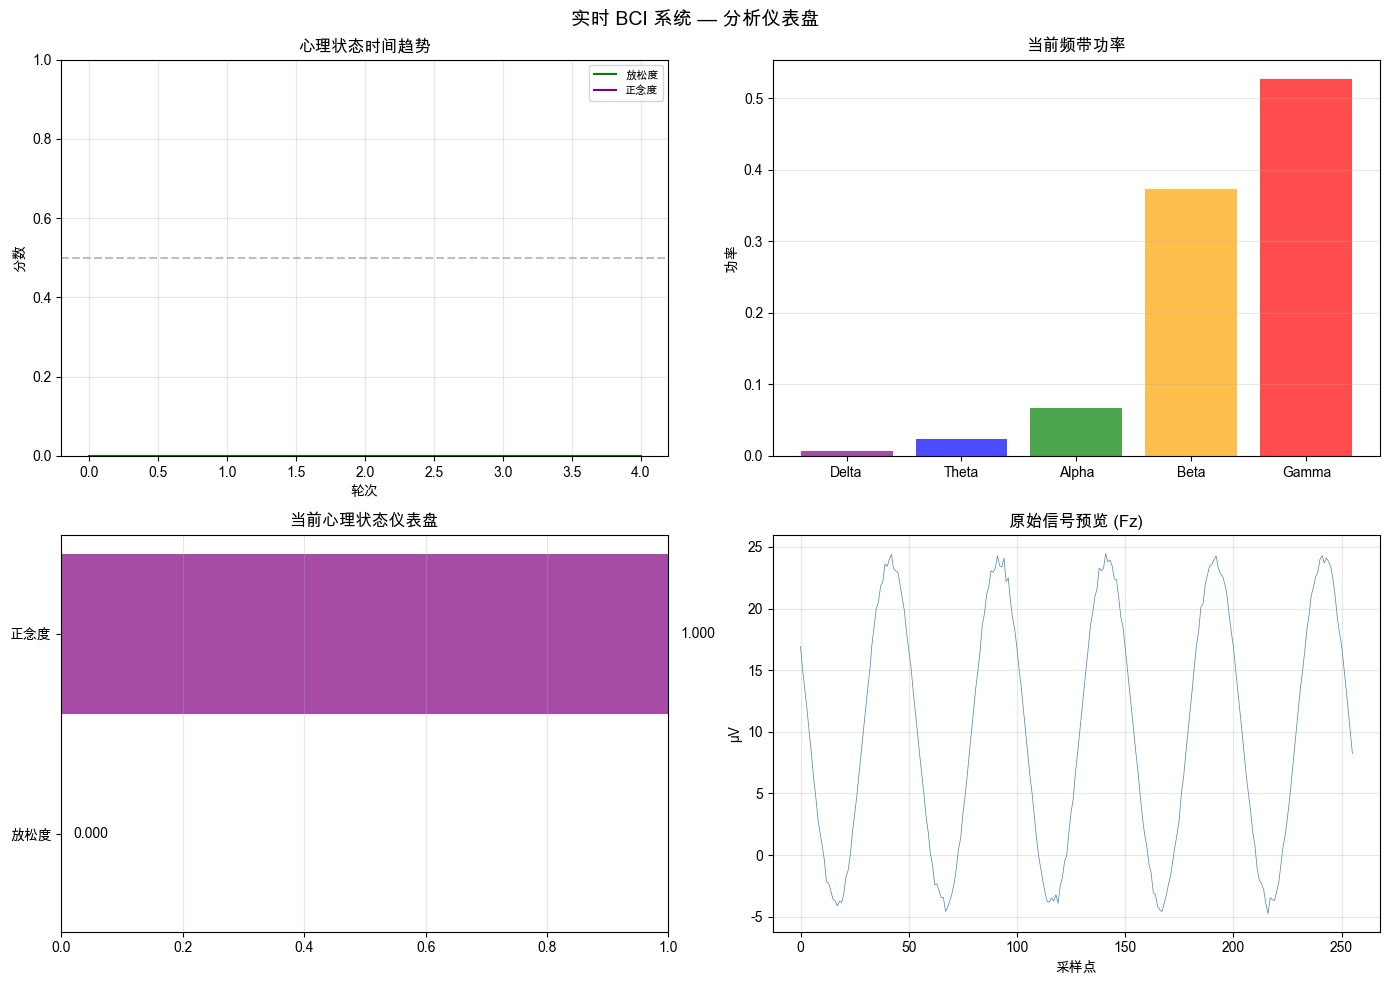

In [6]:
# 可视化实时分析结果
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 心理状态指标趋势
ax = axes[0, 0]
n_points = len(bci.metric_history['restfulness']) # 轮次
x = list(range(n_points))
ax.plot(x, list(bci.metric_history['restfulness']), label='放松度', color='green', linewidth=1.5)
ax.plot(x, list(bci.metric_history['mindfulness']), label='正念度', color='purple', linewidth=1.5)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_ylim(0, 1)
ax.set_title('心理状态时间趋势')
ax.set_xlabel('轮次')
ax.set_ylabel('分数')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 2. 最新一轮频带功率
ax = axes[0, 1]
last_result = bci.analyze()
if last_result:
    band_names = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']
    colors = ['purple', 'blue', 'green', 'orange', 'red']
    bp = last_result['band_powers']
    bars = ax.bar(band_names, bp, color=colors, alpha=0.7)
    ax.set_title('当前频带功率')
    ax.set_ylabel('功率')
    ax.grid(True, alpha=0.3, axis='y')

# 3. 最新心理状态仪表盘
ax = axes[1, 0]
if last_result:
    metrics = ['放松度', '正念度']
    values = [last_result['restfulness'], last_result['mindfulness']]
    bars = ax.barh(metrics, values, color=['green', 'purple'], alpha=0.7)
    ax.set_xlim(0, 1)
    ax.set_title('当前心理状态仪表盘')
    ax.grid(True, alpha=0.3, axis='x')
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontweight='bold')

# 4. 原始信号预览（Fz 通道）
ax = axes[1, 1]
current_data = bci.board.get_current_board_data(256)
if current_data.shape[1] > 0:
    eeg_ch = bci.eeg_channels[0]
    ax.plot(current_data[eeg_ch, -256:], linewidth=0.5, color='steelblue')
    ax.set_title(f'原始信号预览 ({bci.eeg_names[0]})')
    ax.set_xlabel('采样点')
    ax.set_ylabel('μV')
    ax.grid(True, alpha=0.3)

plt.suptitle('实时 BCI 系统 — 分析仪表盘', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Part B: 持续运行与数据记录

模拟一个完整的实验会话：持续运行、定期采样、保存结果。

资源已释放
ML 模型初始化就绪
系统就绪 | 板卡: Synthetic | 采样率: 250 Hz | 窗口: 4秒 (1000样本)
数据流已启动
✅ 数据流记录已启用 → ../data/capstone_recording.csv

=== 模拟认知实验会话 ===
阶段1: 基线 (10秒) ...
阶段2: 任务期 (10秒) ...
阶段3: 恢复期 (10秒) ...

=== 实验结果汇总 ===
阶段       放松度        专注度        正念度       
----------------------------------------
基线       0.0000     1.0000    
任务       0.0000     1.0000    
恢复       0.0000     1.0000    

✅ 结果已保存到 ../data/capstone_results.json


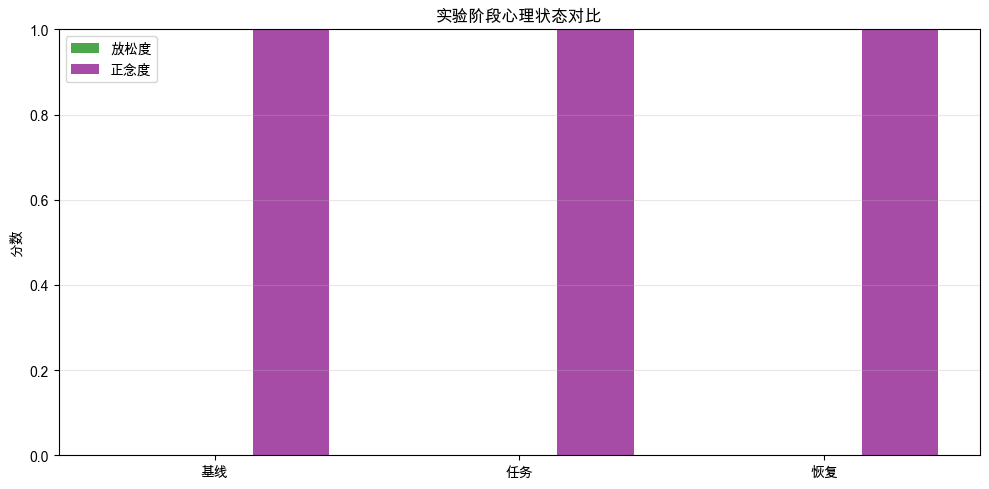

In [17]:
# 停止之前的系统
bci.stop()

# 重新启动并添加数据流记录
bci = BCIRealTimeSystem(
    board_id=BoardIds.SYNTHETIC_BOARD,
    window_sec=4,
    update_interval=0.5
)
bci.start()

# 添加 streamer 将原始数据保存到文件
bci.board.add_streamer(
    streamer_params="file://../data/capstone_recording.csv:w", 
    preset=BrainFlowPresets.DEFAULT_PRESET
)
print("✅ 数据流记录已启用 → ../data/capstone_recording.csv")

# 模拟实验会话
print("\n=== 模拟认知实验会话 ===")
print("阶段1: 基线 (10秒) ...")
time.sleep(3)
bci.board.insert_marker(10)  # 基线标记

baseline_results = []
for i in range(3):
    result = bci.analyze()
    if result:
        baseline_results.append(result)
    time.sleep(1)

print("阶段2: 任务期 (10秒) ...")
bci.board.insert_marker(20)  # 任务开始标记

task_results = []
for i in range(3):
    result = bci.analyze()
    if result:
        task_results.append(result)
    time.sleep(1)

print("阶段3: 恢复期 (10秒) ...")
bci.board.insert_marker(30)  # 恢复期标记

recovery_results = []
for i in range(3):
    result = bci.analyze()
    if result:
        recovery_results.append(result)
    time.sleep(1)

bci.board.insert_marker(99)  # 实验结束

# 汇总对比
def avg_metric(results, key):
    vals = [r[key] for r in results if r is not None]
    return np.mean(vals) if vals else 0

print("\n=== 实验结果汇总 ===")
phases = [
    ("基线", baseline_results),
    ("任务", task_results),
    ("恢复", recovery_results),
]

print(f"{'阶段':<8} {'放松度':<10} {'专注度':<10} {'正念度':<10}")
print("-" * 40)
for phase_name, phase_results in phases:
    r = avg_metric(phase_results, 'restfulness')
    m = avg_metric(phase_results, 'mindfulness')
    print(f"{phase_name:<8} {r:<10.4f} {m:<10.4f}")

# 保存结果
import json
results_summary = {
    'baseline': {k: avg_metric(baseline_results, k) 
                 for k in ['restfulness', 'mindfulness']},
    'task': {k: avg_metric(task_results, k) 
             for k in ['restfulness', 'mindfulness']},
    'recovery': {k: avg_metric(recovery_results, k) 
                 for k in ['restfulness', 'mindfulness']},
}
with open('../data/capstone_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)
print(f"\n✅ 结果已保存到 ../data/capstone_results.json")

# 对比可视化
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(phases))
width = 0.25

ax.bar(x - width, [avg_metric(p[1], 'restfulness') for p in phases], 
       width, label='放松度', color='green', alpha=0.7)
ax.bar(x + width, [avg_metric(p[1], 'mindfulness') for p in phases], 
       width, label='正念度', color='purple', alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(['基线', '任务', '恢复'])
ax.set_ylabel('分数')
ax.set_ylim(0, 1)
ax.set_title('实验阶段心理状态对比')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# 清理资源
bci.stop()
print("✅ 实验会话结束，资源已释放")

## Part C: PyQtGraph 高性能实时可视化（可选）

如果你安装了 `pyqtgraph` 和 `PyQt5`，可以运行以下代码获得流畅的实时信号可视化。

> **注意**：pyqtgraph 需要在主线程中运行 QApplication，在 Jupyter 中可能不稳定。
> 以下代码设计为**独立 Python 脚本**运行。你可以将其保存为 `realtime_viewer.py` 并在终端中执行。

In [ ]:
# realtime_viewer.py — 独立运行的实时 BCI 可视化脚本
# 用法: python realtime_viewer.py

REALTIME_VIEWER_CODE = '''
"""
实时 BCI 信号可视化
使用 pyqtgraph 实现高性能实时渲染

依赖: pip install pyqtgraph PyQt5 brainflow numpy
用法: python realtime_viewer.py
"""

import sys
import numpy as np
from collections import deque

from brainflow.board_shim import BoardShim, BrainFlowInputParams, BoardIds
from brainflow.data_filter import DataFilter, FilterTypes, DetrendOperations

import pyqtgraph as pg
from pyqtgraph.Qt import QtWidgets, QtCore


class RealTimeViewer:
    def __init__(self):
        # BrainFlow 设置
        self.board_id = BoardIds.SYNTHETIC_BOARD
        self.descr = BoardShim.get_board_descr(self.board_id)
        self.sampling_rate = self.descr["sampling_rate"]
        self.eeg_channels = self.descr["eeg_channels"]
        self.eeg_names = BoardShim.get_eeg_names(self.board_id)
        
        # 显示参数
        self.display_seconds = 5
        self.display_points = self.display_seconds * self.sampling_rate
        
        # 数据缓冲
        self.buffers = [deque(maxlen=self.display_points) for _ in self.eeg_channels]
        
        # 启动板卡
        params = BrainFlowInputParams()
        self.board = BoardShim(self.board_id, params)
        self.board.prepare_session()
        self.board.start_stream(450000)
        
        # 初始化 GUI
        self._init_gui()
        
    def _init_gui(self):
        pg.setConfigOption("background", "w")
        pg.setConfigOption("foreground", "k")
        
        self.app = QtWidgets.QApplication(sys.argv)
        self.win = pg.GraphicsLayoutWidget(title="BCI Real-Time Viewer", size=(1000, 700))
        self.win.show()
        
        # 时域图
        self.plots = []
        self.curves = []
        colors = ["#A54E4E", "#A473B6", "#5B45A4", "#2079D2",
                  "#32B798", "#2FA537", "#9DA52F", "#A53B2F"]
        
        for i in range(len(self.eeg_channels)):
            p = self.win.addPlot(row=i, col=0)
            p.showAxis("left", False)
            p.setMenuEnabled("left", False)
            p.showAxis("bottom", i == len(self.eeg_channels) - 1)
            p.setMenuEnabled("bottom", False)
            if i == 0:
                p.setTitle(f"EEG Signals ({self.descr['name']}, {self.sampling_rate} Hz)")
            self.plots.append(p)
            
            pen = pg.mkPen({"color": colors[i], "width": 1})
            curve = p.plot(pen=pen)
            self.curves.append(curve)
        
        # 定时器
        self.timer = QtCore.QTimer()
        self.timer.timeout.connect(self._update)
        self.timer.start(50)  # 50ms 更新间隔
        
    def _update(self):
        """定时更新显示"""
        data = self.board.get_current_board_data(self.sampling_rate // 4)
        
        if data.shape[1] > 0:
            for i, ch in enumerate(self.eeg_channels):
                ch_data = data[ch, :].copy()
                # 简单预处理
                DataFilter.detrend(ch_data, DetrendOperations.CONSTANT.value)
                DataFilter.perform_bandpass(ch_data, self.sampling_rate,
                                             25.25, 49.5, 4,
                                             FilterTypes.BUTTERWORTH.value, 0)
                
                for val in ch_data:
                    self.buffers[i].append(val)
                
                self.curves[i].setData(list(self.buffers[i]))
    
    def run(self):
        """启动应用"""
        try:
            QtWidgets.QApplication.instance().exec_()
        finally:
            self.board.stop_stream()
            self.board.release_session()


if __name__ == "__main__":
    viewer = RealTimeViewer()
    viewer.run()
'''

# 保存为独立脚本
import os
os.makedirs("scripts", exist_ok=True)
with open("scripts/realtime_viewer.py", "w", encoding="utf-8") as f:
    f.write(REALTIME_VIEWER_CODE)
print("✅ 独立脚本已保存到: scripts/realtime_viewer.py")
print("运行方式: python scripts/realtime_viewer.py")

## 系统架构总结

### 数据流

```text
Synthetic Board (模拟EEG)
       │
       ▼
BoardShim.start_stream()  ← 环形缓冲区
       │
       ├─ get_current_board_data(n)  ← 实时获取
       │        │
       │        ▼
       │   [预处理] detrend → bandpass → notch
       │        │
       │        ▼
       │   [特征] get_avg_band_powers() → 5维频带功率
       │        │
       │        ▼
       │   [ML推理] MLModel.predict() → 放松度/专注度/正念度
       │        │
       │        ▼
       │   [可视化] matplotlib / pyqtgraph 实时更新
       │
       └─ add_streamer()  ← CSV 文件记录
```

### 关键设计模式

1. **环形缓冲区**：`get_current_board_data(n)` 不消耗数据，允许独立消费者
2. **滑动窗口**：固定时间窗口分析，平衡时域分辨率和频域分辨率
3. **分离关注点**：采集(Shim) → 处理(Filter) → 推理(ML) 各模块独立
4. **优雅关闭**：使用 try/finally 确保资源释放

### 从模拟到真实硬件

切换到真实 EEG 设备仅需修改两行代码：

```python
# 模拟 (Synthetic)
board_id = BoardIds.SYNTHETIC_BOARD
params = BrainFlowInputParams()

# 真实 Cyton 设备
board_id = BoardIds.CYTON_BOARD
params = BrainFlowInputParams()
params.serial_port = "COM3"  # 或 /dev/ttyUSB0 (Linux/Mac)

# 其余代码完全不变！
```

### 进一步探索方向

- 使用 scikit-learn 训练自定义分类器（如左右手运动想象）
- 集成 ONNX 模型进行更复杂的心理状态分类
- 添加 Neurofeedback 神经反馈循环
- 使用 LSL (Lab Streaming Layer) 与其他应用集成
- 结合 MNE-Python 进行专业的 EEG 分析

---

🎉 **恭喜完成全部学习计划！**